## P4DS Summative Assignment 2

# Data Analysis Project

#### Notebook template design: Brandon Bennett (revised 01/02/2023 NA)

# Correlating Income, House Prices, and Happiness in Greater London


#### Student: Wesley Chiu

#### Email: od22wc@leeds.ac.uk

# Project Plan

## The Data (10 marks)

### Dataset 1: Price Paid Data (HM Land Registry)
**Link to source webpage:** [Price Paid Data](https://www.gov.uk/government/statistical-data-sets/price-paid-data-downloads)

**Direct link to dataset:** [Price Paid Transaction Data (Single File) (4.3Gb)](http://prod.publicdata.landregistry.gov.uk.s3-website-eu-west-1.amazonaws.com/pp-complete.csv)


**Attribution Statement:** Contains HM Land Registry data © Crown copyright and database right 2021. This data is licensed under the Open Government Licence v3.0.


#### Description:
The Price Paid Data, provides a single file for all transaction data on prices paid for each property sales in England and Wales, which is submitted to HM Land Registry for registration. The file is updated monthly, and contains data from 1995 to present (retrieved as at 24 April 2023).

The following fields are available in the file, any field marked with an asterisk will not be used in this project:

| **Field** | **Data Type** | **Description** |
| :- | :-: | :- |
|Transaction unique identifier | Object | A unique reference number generated for each published sale |
| Price | Float | Sale price stated on the transfer deed (in GBP) |
| Date of Transfer | Date | Date when the sale was completed |
| Postcode | String | Postcode of the property at the time of sale |
| Property Type | String | D = Detached, S = Semi-Detached, T = Terraced, F = Flats/Maisonettes, O = Other |
| Old/New | String | Y = Newly built property, N = Not newly built |
| Duration | String | F = Freehold, L = Leasehold |
| PAON* | String | Primary Addressable Object Name (usually house number) |
| SAON* | String | Secondary Addressable Object Name (e.g. flats) |
| Street* | String | Street name |
| Locality | String | Local town name |
| Town/City | String | Town/City |
| District | String | District |
| County | String | County - for this analysis, we will use only rows where Country == 'GREATER LONDON' |
| PPD Category Type | String | A = Standard Price Paid, B = Additional Price Paid (e.g. buy-to-lets, reposessions, etc.) |

### Dataset 2: Earnings by Place of Residence, Borough
**Link to source webpage:** [Earnings by Place of Residence, Borough](https://data.london.gov.uk/dataset/earnings-place-residence-borough)

**Direct link to dataset:** [earnings-residence-borough.xls](https://data.london.gov.uk/download/earnings-place-residence-borough/1686ef1c-b169-442d-8877-e7e49788f668/earnings-residence-borough.xlsx)

#### Description:
The Earnings by Place of Residence, Borough provides the median income at varying levels of employment (Full-Time vs Part-Time) at Weekly and Hourly levels, as well as a perspective on the data by gender, by borough, for the Greater London area.
The dataset captures data points from the years 2002 to 2021.

Note that in 2006, a number of methdological changes were made. As the change in methodology only affects a limited number of years, the impact of these changes will not be considered.

For the purposes of this report, only Full-Time income by Borough will be used as as a measure of wealth by area.

### Dataset 3: Personal Well-being (Happiness) by Borough
**Link to source webpage:** [Personal Well-being (Happiness) by Borough](https://data.london.gov.uk/dataset/subjective-personal-well-being-borough)

**Direct link to dataset:** [Personal Well-being by Borough](https://data.london.gov.uk/download/subjective-personal-well-being-borough/d1bae8e8-f07b-4c2f-aec7-deed8006b52a/personal-well-being-borough.xlsx)

The Personal Well-being (Happiness) by Borough dataset provides the mean scores for each borough in a survey that asked survey respondents to answer questions relating to:
* Life satisfaction
* "Meaningful-ness" of life
* Happiness
* Anxiety

A score was provided for each question, where 0 = "Not at all" and 10 = "Completely". The dataset captures data from the years 2012 to 2019.

For the purposes of this report, only the mean score by year and borough will be used as a measure of 'happiness' and 'anxiety'.


## Project Aim and Objectives (5 marks)

The primary aim of this project is to discover if there is a **correlation** between house price, median income, and feelings of personal well-being across London.

In this report we test two main hypotheses:
1. Is an increase in house price related to increasing income? (i.e. gentrification)
2. Can money buy happiness?

### 1. House price and Income
These two metrics are popular indicators for measuring the wealth of a population and are of particular interest to government and to economic bodies (such as the [OECD](https://data.oecd.org/price/housing-prices.htm)).
This report seeks to determine whether income and the price paid for residential property in a borough can be **correlated**. 

### 2. Can money buy happiness?
While there are undoubtedly many factors that go to inform a person's well-being and happiness, this report will seek to establish if median income can be **correlated** with stronger feelings of happiness.

### Specific Objective(s)

* __Objective 1:__ Visualize changes in house price, median income, and well-being from the years 2006 to 2021 (the period of time where data is available from both the Price Paid Data (Dataset 1) and Earnings by Place of Residence, Borough (Dataset 2)
* __Objective 2:__ Determine whether median income for each borough correlates with growth in house prices
* __Objective 3:__ Determine whether higher median income leads to better feelings of personal well-being

## System Design (5 marks)


### Architecture

1. Data ingestion
    * Reading the data into a pandas dataframe
2. Data cleaning and wrangling 
    * Removing missing or irrelevant data
    * Reshaping the data into a consistent format so that the datasets can be joined together
    * Rescaling the measures to remove impact that the differences in magnitude may make on analysis
3. Data exploration
    * Creating a side-by-side time-series line chart so that the datasets can be compared
4. Joining datasets
    * Using ```pandas``` to merge datasets so that analysis can be done
5. Correlation and Visualisation
    * Using the ```pandas``` correlation function to find the Pearson correlation between measures
    * Visualising the correlation data by borough
  
### Processing Modules and Algorithms

* Importing data into a ```pandas``` dataframe, cleaning data to remove irrelevant and missing data, and reformatting / reshaping the data so that datasets can be joined
* Rescaling median price paid in dataset 1, so that median price paid growth can be more easily compared across boroughs
* Combining datasets 1 & 2, and 2 & 3 into a single dataframe
* Calculating the Pearson correlation between median price paid by borough, by year, against measures of income and happiness, and visualising the data in a horizontal bar chart

# Program Code (15 marks)

_Your code should be divided into relatively short cells, with brief
explanation in markup cells between._

_As noted in the assigment overview, it is not necessary that your coding be
super complex in order to get a good mark. Although there is a mark for
the coding achievement, it is only a quarter of the total._

_The suggested length of the code is about 200 lines.
You should not use more than 500 lines of code._

_You should divide the code in accordance with the specification of modules and/or
algorithms you gave in the previous section. Complex modules should be further
divided into several code cells._

Please note the following about your code:
* <b><i>You may import any packages/modules you wish to use for your project.</i></b>
* <b><i>You should submit your notebook in a state where all cells have been
    executed and are displaying the output that you wish to present for grading.</i></b>
    <br>
    (We will not normally run your code, unless for some reason we wish to check
    that the code functionality matches the given description.)</br>

#### _Brief Explanation of following code cell_

Importing required packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

#### _Brief Explanation of following code cell_
Reading in the full file of Dataset 1: Price Paid Data into a pandas dataframe. 

As the full file is quite large, we will filter for only datapoints relevant to the Greater London area, for the time period that this report will be investigating (2006 to 2021); the filtered dataframe will then be saved as a separate file.

In [ ]:
# Creating a subset of the datasource to avoid working with a file that is too large
column_headers = ['txn_unique_id', 'price', 'date', 'postcode', 'property_type'
                 ,'old_or_new', 'duration', 'primary_addressable_object_name', 'secondary_addressable_object_name'
                 ,'street', 'locality', 'town_city', 'district', 'county', 'ppd_category_type'
                 ,'record_status']

df = pd.read_csv('pp-complete.csv', names=column_headers)

og_file_rows = df.shape[0]
print(f'Number of rows in original file: {og_file_rows}')

df_london = df[df['county']=='GREATER LONDON']
print(f'Number of rows relating to Greater London: {df_london.shape[0]}')
print(f'Greater London represents {round(df_london.shape[0]/og_file_rows*100,2)}% of the original file')

# Releasing memory from original file
del df

# Saving new file
df_london.to_csv('pp-complete-london.csv', index=False)
del df_london

# Re-opening pp-complete-london.csv
df_ppd = pd.read_csv('pp-complete-london.csv')
df_ppd.head()

#### _Comment on previous cell output_

The outputs above indicate that data relating to the Greater London area represents approximately 13% of the full dataset. By saving the resulting (smaller) dataframe as a separate csv file, we are able to comment out the preceeding lines of code for a faster run-time (if required). We also deleted the dataframes to release system memory and free up resources for other activities (for example, running analysis described in the remaining sections of this report).

Finally, the top 5 rows of the new dataframe (``df_ppd``) is printed to give a sample of the data to the reader.

In [2]:
# Re-opening pp-complete-london.csv
df_ppd = pd.read_csv('pp-complete-london.csv')

#### _Brief Explanation of following code cell_

As we are only interested median price paid by transaction year at the 'borough' level, which in Dataset 1 is represented by the field ```district```, the following columns will not be necessary and can be dropped:
* primary addressable_object_name
* secondary_addressable_object_name
* street
* locality
* town_city
* postcode

Additionally, as we will be finding the median price paid, we will also not require the individual transaction IDs.

In [3]:
cols_to_drop = ['primary_addressable_object_name', 'secondary_addressable_object_name', 'street'
               , 'locality', 'town_city', 'postcode', 'txn_unique_id']

df_ppd.drop(columns=cols_to_drop, inplace=True)

#### _Brief Explanation of following code cell_
To better understand the data that is in the dataframe, a print of the data types by column and the number of nulls / NaN is shown

In [5]:
print(df_ppd.info())

print('---Testing for null / NaN entries in dataset---')
print(df_ppd.isnull().any())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3604971 entries, 0 to 3604970
Data columns (total 9 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   price              int64 
 1   date               object
 2   property_type      object
 3   old_or_new         object
 4   duration           object
 5   district           object
 6   county             object
 7   ppd_category_type  object
 8   record_status      object
dtypes: int64(1), object(8)
memory usage: 247.5+ MB
None
---Testing for null / NaN entries in dataset---
price                False
date                 False
property_type        False
old_or_new           False
duration             False
district             False
county               False
ppd_category_type    False
record_status        False
dtype: bool


#### _Comment on previous cell output_
The output also indicates that there are no missing values in the dataset, so no further cleaning is required at this stage

#### _Brief Explanation of following code cell_
As we are interested in the median price paid per year, the below cell extracts the ```year``` component (which is a ```string```), and removes the ```date``` field, as it is no longer required

In [6]:
df_ppd['Year'] = df_ppd['date'].apply(lambda x: int(x[:4]))
df_ppd.drop(columns='date', inplace=True)
df_ppd.rename(columns={'district' : 'Area'}, inplace=True)
df_ppd.head(2)

,price,property_type,old_or_new,duration,Area,county,ppd_category_type,record_status,Year
0,121250,F,N,L,BARNET,GREATER LONDON,A,A,1995
1,128500,T,N,F,WANDSWORTH,GREATER LONDON,A,A,1995


#### _Brief Explanation of following code cell_
The cell below filters for the date range we are interested in (2006 to 2021) and calculates the median price paid by borough by year, and presents the output as a multi-index

In [7]:
df_ppd = df_ppd[(df_ppd['Year'] >= 2006) & (df_ppd['Year'] <= 2021)].groupby(by=['Area', 'Year']).median()
df_ppd.head(2)

price
Area                 Year          
BARKING AND DAGENHAM 2006  168000.0
                     2007  185000.0

#### _Brief Explanation of following code cell_
Importing Dataset 2: Earnings by Place of Residence, Borough

The data, as presented in the excel, has a multi-index for the first two rows, which will need to be recognised by ```pandas```.
The data then presents a blank row and a row of invalid data for the ```City of London``` - these rows will be skipped when reading into a dataframe.

In [8]:
df_earnings = pd.read_excel('earnings-residence-borough.xlsx', sheet_name='Total, weekly'
                            , header = [0,1], skiprows=[2,3])
df_earnings.head()

Code                  Area    2002           2003         \
  Unnamed: 0_level_1    Unnamed: 1_level_1 Pay (£) conf % Pay (£) conf %   
0               00AB  Barking and Dagenham   383.3    5.5   354.9    6.5   
1               00AC                Barnet   427.4    5.1   450.1    5.0   
2               00AD                Bexley   405.0    5.0   431.9    5.1   
3               00AE                 Brent   368.4    5.8   359.8    5.0   
4               00AF               Bromley   440.1    5.1   449.2    4.8   

     2004           2005         ...    2017           2018           2019  \
  Pay (£) conf % Pay (£) conf %  ... Pay (£) conf % Pay (£) conf % Pay (£)   
0   360.1    5.2   375.1    5.1  ...   461.0    5.1   479.1    4.9   471.0   
1   453.3    5.6   442.3    5.3  ...   522.6    4.5   536.6    4.6   536.4   
2   438.1    5.5   452.4    5.3  ...   513.0    4.6   512.7    5.4   553.4   
3   395.5    5.4   394.7    4.4  ...   471.0    4.7   479.9    3.9   524.0   
4   461.2    4.5   464.8    4.5  ...   608.0    4.8   632.7    4.3   638.3   

            2020           2021         
  conf % Pay (£) conf % Pay (£) conf %  
0    6.1   486.7    6.5   523.5    7.5  
1    4.4   538.8    4.1   574.9    5.9  
2    5.1   566.5    7.6   584.8    5.8  
3    4.0   531.8    6.3   553.1    5.3  
4    5.0   613.2    7.0   653.0    6.3  

[5 rows x 42 columns]

#### _Comment on previous cell output_
The dataframe above shows that the median earnings by year is accompanied with a confidence %; for the purposes of this report, we will ignore the confidence range and drop those columns. Additionally, we will need to remove the ```Code``` column, as this will not be used.

#### _Brief explanation of following code cell_
The below code cell removes the ```Code``` column, formats the string for ```Area``` and removes the ```conf %``` columns for each year. As the multi-index for columns is no longer relevant after these steps are run, the cell also drops the 'second' level.

Finally, to match the format of Dataset 1, the cell will pivot the data so that the index will be of the form ```[Area, Year]```.

In [9]:
cols_to_drop = [col for col in df_earnings.columns if 'conf %' in col]
df_earnings.drop(columns=cols_to_drop, inplace=True)
df_earnings.columns = df_earnings.columns.droplevel(1)
df_earnings['Area'] = df_earnings['Area'].str.upper()

# Removing non-Greater London areas (denoted in data by a 4-character code)
df_earnings[('Code_Len')] = df_earnings['Code'].apply(lambda x: len(str(x)))
df_earnings = df_earnings[df_earnings['Code_Len']==4]
df_earnings.drop(columns=['Code', 'Code_Len'], inplace=True)

df_earnings = pd.melt(df_earnings, id_vars=['Area'], var_name='Year', value_name='earnings')
df_earnings = df_earnings[(df_earnings['Year']>=2006) & (df_earnings['Year'] <= 2021)].groupby(by=['Area','Year']).median()
df_earnings.head()

earnings
Area                 Year          
BARKING AND DAGENHAM 2006     417.6
                     2007     446.7
                     2008     449.9
                     2009     448.8
                     2010     429.3

#### _Brief Explanation of following code cell_
Importing Dataset 3: Personal Well-being (Happiness) by Borough

The data, as presented in the ```.xlsx``` file, has two header rows, which will need to be interpreted by ```pandas``` as a multi-index. The data also has a blank row after the header and includes a row for the ```City of London```, which has invalid data that will need to be ignored.

In [10]:
df_happiness = pd.read_excel('personal-well-being-borough.xlsx', sheet_name='Summary - Mean Scores'
                          , header=[0,1], skiprows=[2,3])
df_happiness.head()

Life Satisfaction                          \
        Code                  Area           2011/12 2012/13 2013/14 2014/15   
0  E09000002  Barking and Dagenham              7.05    7.09    7.01    7.32   
1  E09000003                Barnet              7.43    7.28    7.40    7.54   
2  E09000004                Bexley              7.42    7.42    7.28    7.52   
3  E09000005                 Brent              7.11    7.28    7.41    7.24   
4  E09000006               Bromley              7.50    7.60    7.53    7.71   

                                   ... Happiness           Anxiety          \
  2015/16 2016/17 2017/18 2018/19  ...   2018/19 2018/19.1 2011/12 2012/13   
0    7.45    7.50    7.66    7.52  ...      7.67       NaN    3.23    3.27   
1    7.53    7.47    7.63    7.55  ...      7.44       NaN    3.41    2.74   
2    7.41    7.46    7.42    7.54  ...      7.55       NaN    3.07    3.24   
3    7.55    7.67    7.79    7.71  ...      7.84       NaN    2.77    3.29   
4    7.54    7.60    7.31    7.57  ...      7.47       NaN    3.30    3.22   

                                                   
  2013/14 2014/15 2015/16 2016/17 2017/18 2018/19  
0    3.39    3.15    2.84    3.02    2.85    2.82  
1    2.60    2.37    2.49    3.09    2.78    3.19  
2    3.46    3.16    3.06    3.16    3.04    3.21  
3    3.07    2.50    2.57    2.69    2.70    2.40  
4    3.15    2.76    2.98    3.29    3.16    2.88  

[5 rows x 37 columns]

#### _Comment on previous cell output_
The dataframe shows that there are several changes that need to be made to the data to match the structure of ```df_ppd``` and ```df_earnings``` dataframes.

#### _Brief Explanation of following code cell_
To match the structure of ```df_ppd``` and ```df_earnings``` dataframes, the structure of ```df_happiness```, the following changes will be made in the cell below:
* Remove any blank columns from the dataframe
* Change ```Year``` from string to int (assume that the year will be the ending year - i.e. "2011/12" == 2012)
* Pivot the data such that the index is set by Area and Year, while the Columns represent the median values for each well-being factor

In [11]:
# Dropping empty rows
original_row_count = df_happiness.shape[0]
df_happiness.dropna(how='all', inplace=True)
print(f'Dropped {original_row_count - df_happiness.shape[0]} empty rows')

# Dropping empty columns
cols_to_drop = [col for col in df_happiness.columns if df_happiness[col].isnull().all()]
cols_to_drop.append((' ', 'Code'))
df_happiness.drop(columns=cols_to_drop, inplace=True)
print(f'Dropped {len(cols_to_drop)} empty columns')

# Re-shaping data
df_happiness = pd.melt(df_happiness, id_vars=[(' ', 'Area')], var_name=['Factor', 'Year'], value_name='Median')
df_happiness['Year'] = df_happiness['Year'].apply(lambda x: int(x[:2] + x[-2:]))
df_happiness.rename(columns={(' ', 'Area') : 'Area'}, inplace=True)
df_happiness['Area'] = df_happiness['Area'].str.upper()
df_happiness = df_happiness.pivot(index=['Area', 'Year'], columns='Factor', values='Median')
df_happiness.head(2)

Dropped 3 empty rows
Dropped 4 empty columns


Factor                     Anxiety  Happiness  Life Satisfaction  Worthwhile
Area                 Year                                                   
BARKING AND DAGENHAM 2012     3.23       6.91               7.05        7.49
                     2013     3.27       7.05               7.09        7.60

#### _Brief Explanation of following code cell_
Two 'helper' functions are shown below; these helper functions are able to be generalised across all the plots required to answer Objective 1.

```format_chart```: This function sets the x-axis and y-axis limits, sets and formats the axis labels, and enables gridlines

```rescale_dimesion```: This function rescales the measure of interest (e.g. earnings) and indexes all subsequent years against a base year. For example, if the base year was ```2006```, then we would rescale the value at ```2007``` as a proportion of the ```2006```. Doing this allows the comparison of growth across different boroughs, that may have different base values. For example, one borough may have a median price paid in 2006 of 150000, while another may have a base value of 300000 - a plot of the exact values for each borough would be difficult to demonstrate the change in growth between boroughs.

In [12]:
def format_chart(ax, df, xlabel, ylabel):
    ax.set_xlim([df.index.get_level_values(1).min(), df.index.get_level_values(1).max()+1])
    ax.set_ylim([0, df.rescaled.max() * 1.1])
    ax.set_xlabel(xlabel, fontweight='bold')
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.grid(which='major', axis='both', linewidth=0.3, alpha=0.5)

def rescale_dimension(df_original, column_to_rescale, base_year, time_series, rescale_by):
    df = df_original.reset_index()
    df = df.assign(base = lambda x: 
                   df[(df[rescale_by]==x[rescale_by]) & (df[time_series]==base_year)][column_to_rescale])
    
    df['base'] =df['base'].ffill(axis=0)
    df['rescaled'] = df[column_to_rescale]/df['base']
    
    return df    

#### _Brief Explanation of following code cell_
A function to visualise Dataset 1, showing ```Year``` on the x-axis and ```Median Price Paid``` on the y-axis, where each line is a separate borough.

The function then plots a line chart of the median price paid over time for all boroughs, highlighting the borough that experienced the greatest growth in green, the borough with the greatest growth when we exclude the City of London in blue (to match the available data in other datasets), and the borough with the lowest growth in red, with all other boroughs illustrated in a semi-opaque grey line.

In [13]:
def plot_ppd(df_original, ax):
    # Re-scaling the dataframe to index based in 2006 median value, 
    # so we can easily visualise which borough has experienced the greatest
    # rise in price paid
    df = rescale_dimension(df_original, 'price', 2006, 'Year', 'Area')
    
    # Finding boroughs with the highest and lowest growth
    highest_growth_district = df.iloc[df[df['Year']==2021]['rescaled'].idxmax()]['Area']
    highest_growth_excl_col = df.iloc[df[(df['Year']==2021) & (df['Area']!='CITY OF LONDON')]['rescaled']
                                      .idxmax()]['Area']
    lowest_growth_district = df.iloc[df[df['Year']==2021]['rescaled'].idxmin()]['Area']
        
    df = df.groupby(by=['Area', 'Year']).median()

    for ind in df.index.get_level_values(0).unique():
        df_ind = df.xs(ind)
        x = df_ind.index
        y = df_ind['rescaled']

        if ind == highest_growth_district:
            ax.plot(x, y, label=ind, color = 'green')
            ax.text(list(x)[-1]-0.2, list(y)[-1] + 0.1, round(list(y)[-1], 2), color='green')
        elif ind == highest_growth_excl_col:
            ax.plot(x, y, label=ind, color = 'blue')
            ax.text(list(x)[-1], list(y)[-1], round(list(y)[-1], 2), color='blue')
        elif ind == lowest_growth_district:
            ax.plot(x, y, label=ind, color = 'red')
            ax.text(list(x)[-1]-0.2, list(y)[-1] - 0.1, round(list(y)[-1], 2), color='red')
        else:
            ax.plot(x, y, color = 'grey', alpha = 0.4, linewidth = 0.6)

    # Formatting chart
    format_chart(ax, df, 'Year', 'Median Price Paid at 2006 base index')
    ax.legend()

#### _Brief Explanation of following code cell_
The below function plots the change in median full-time weekly earnings by borough across time.

In [14]:
def plot_earnings(df_original, ax):
    # Re-scaling the dataframe to index based in 2006
    df = rescale_dimension(df_original, 'earnings', 2006, 'Year', 'Area')
    
     # Finding boroughs with the highest and lowest growth
    highest_growth_district = df.iloc[df[df['Year']==2021]['rescaled'].idxmax()]['Area']
    lowest_growth_district = df.iloc[df[df['Year']==2021]['rescaled'].idxmin()]['Area']
    
    df = df.groupby(by=['Area', 'Year']).median()
    
    # Plotting chart
    for ind in df.index.get_level_values(0).unique():
        df_ind = df.xs(ind)
        x = df_ind.index
        y = df_ind['rescaled']

        if ind == highest_growth_district:
            ax.plot(x, y, label=ind, color = 'green')
            ax.text(list(x)[-1], list(y)[-1] + 0.02, round(list(y)[-1], 2), color='green')
        elif ind == lowest_growth_district:
            ax.plot(x, y, label=ind, color = 'red')
            ax.text(list(x)[-1], list(y)[-1] - 0.02, round(list(y)[-1], 2), color='red')
        else:
            ax.plot(x, y, color = 'grey', alpha = 0.4, linewidth = 0.6)

            
    # Formatting chart
    format_chart(ax, df, 'Year', 'Median Full Time Income')
    ax.legend()

#### _Brief Explanation of following code cell_
The below function plots the change in median reported happiness by borough across time.

In [15]:
def plot_happiness(df_original, ax):
    # Re-scaling the dataframe to index based in 2012
    df = rescale_dimension(df_original, 'Happiness', 2012, 'Year', 'Area')
    
     # Finding boroughs with the highest and lowest growth
    highest_growth_district = df.iloc[df[df['Year']==2019]['rescaled'].idxmax()]['Area']
    lowest_growth_district = df.iloc[df[df['Year']==2019]['rescaled'].idxmin()]['Area']
    
    df = df.groupby(by=['Area', 'Year']).median()
    
    # Plotting chart
    for ind in df.index.get_level_values(0).unique():
        df_ind = df.xs(ind)
        x = df_ind.index
        y = df_ind['rescaled']

        if ind == highest_growth_district:
            ax.plot(x, y, label=ind, color = 'green')
            ax.text(list(x)[-1], list(y)[-1] + 0.02, round(list(y)[-1], 2), color='green')
        elif ind == lowest_growth_district:
            ax.plot(x, y, label=ind, color = 'red')
            ax.text(list(x)[-1], list(y)[-1] - 0.02, round(list(y)[-1], 2), color='red')
        else:
            ax.plot(x, y, color = 'grey', alpha = 0.4, linewidth = 0.6)

            
    # Formatting chart
    format_chart(ax, df, 'Year', 'Reported Happiness')
    ax.legend()

#### _Brief Explanation of following code cell_
The below function creates a 1x3 GridSpec figure to plot the three different charts described above, create headings for each chart, and then seeks to align the x and y axes so that all charts share the same scale.

This function is then called during the **Overview of Results** section of the report.

In [16]:
 def obj_one():
    fig, (ax_ppd, ax_earnings, ax_happiness) = plt.subplots(nrows=1, ncols=3, figsize=(15,6))
    
    plot_ppd(df_ppd, ax_ppd)
    plot_earnings(df_earnings, ax_earnings)
    plot_happiness(df_happiness, ax_happiness)
    
    ax_ppd.set_title('Median Price Paid over time', fontweight='bold', fontsize=12)
    ax_earnings.set_title('Median Weekly Full-Time Earnings over time', fontweight='bold', fontsize=12)
    ax_happiness.set_title('Median Happiness over time', fontweight='bold', fontsize=12)
    
    
    # Aligning axes for easier comparison between charts
    axs = [ax_ppd, ax_earnings, ax_happiness]
    
    x_lims = [2006, 0]
    y_lims = [0, 0]
    for ax in axs:
        lims = ax.get_xlim()
        x_lims[1] = max(x_lims[1], lims[1])
        
        lims = ax.get_ylim()
        y_lims[0] = min(y_lims[0], lims[0])
        y_lims[1] = max(y_lims[1], lims[1])
    
    for ax in axs:
        ax.set_xlim([x_lims[0], x_lims[1]])
        ax.set_ylim(y_lims[0], y_lims[1])

    fig.align_xlabels()
    fig.align_ylabels()
    plt.tight_layout()
    plt.show()

#### _Brief Explanation of following code cell_
The function below joins the two datasets by ```[Area, Year]``` and rescales the two measures according to their min-max values (individually) so that the relative magnitude between the measures is removed from the correlation.

The function then calculates the correlation between the two measures by borough, and stores it in a dataframe. The dataframe is then sorted in ascending order, so that the data is more easily understood when it is plotted (in a separate function)

In [17]:
def correlations(df1, df2, measure1, measure2):
    df = pd.merge(df1, df2, on=['Area', 'Year'], how='inner')
    
    borough_corr = {}
    
    for ind in df.index.get_level_values(0).unique():
        df_ind = df.xs(ind)
        df_ind[f'{measure1}_rescaled'] = (df_ind[measure1] - df_ind[measure1].min())/(df_ind[measure1].max() - df_ind[measure1].min())
        df_ind[f'{measure2}_rescaled'] = (df_ind[measure2] - df_ind[measure2].min()) / (df_ind[measure2].max() - df_ind[measure2].min())
        
        borough_corr[ind] = df_ind[f'{measure1}_rescaled'].corr(df_ind[f'{measure2}_rescaled'])
    
    df_corrs = pd.DataFrame.from_dict(borough_corr, orient='index', columns=[f'{measure1}-{measure2}_corr'])
    df_corrs.sort_values(by=[f'{measure1}-{measure2}_corr'], ascending=True, inplace=True)
        
    return df_corrs

#### _Brief Explanation of following code cell_
The function below plots the correlations calculated in the code cell above in a horizontal bar chart, and formats the chart by:
* Adding data labels to each bar
* Removing the spines of the chart
* Adds chart title

In [21]:
def obj_two():
    # Joining the datasets
    df_corrs = correlations(df_ppd
                            , df_earnings
                            , 'price', 'earnings')
    
    # Extracting the x and y labels for the chart
    label_pos = range(df_corrs.shape[0])
    corrs = df_corrs['price-earnings_corr'].values.tolist()
    
    # Creating the figure and establishing bar height
    fig, ax = plt.subplots(figsize=(10,10))
    bar_height = 0.8
    
    ax.barh(label_pos, corrs, height=bar_height)
    ax.set_yticks(label_pos, df_corrs.index)

    # Adding data labels
    for i in range(len(corrs)):
        ax.text(corrs[i] + 0.01, label_pos[i] - bar_height/4, round(corrs[i], 2))

    # Removing spines
    for spine in ax.spines:
        ax.spines[spine].set_visible(False)
        
    ax.set_title('Pearson Correlation between Median Price Paid and Median Earnings by Borough between 2006 and 2021'
                 , fontweight='bold', fontsize=12)

    ax.xaxis.set_tick_params(length=0, labelbottom=False)
    plt.show()

#### _Brief Explanation of following code cell_
The function below joins the Median Earnings and Median Happiness datasets, rescales the two measures according to their min-max values, and plots the result in a horizontal bar chart

In [22]:
def obj_three():
    # Joining the datasets
    df_corrs = correlations(df_earnings
                            , df_happiness
                            , 'earnings'
                            , 'Happiness')
    
    # Extracting the x and y labels for the chart
    label_pos = range(df_corrs.shape[0])
    corrs = df_corrs['earnings-Happiness_corr'].values.tolist()

    # Creating the figure and establishing bar height
    fig, ax = plt.subplots(figsize=(10,10))
    bar_height = 0.8
    
    ax.barh(label_pos, corrs, height=bar_height)
    ax.set_yticks(label_pos, df_corrs.index)

    # Adding data labels
    for i in range(len(corrs)):
        ax.text(corrs[i] + 0.01, label_pos[i] - bar_height/4, round(corrs[i], 2))

    # Removing spines
    for spine in ax.spines:
        ax.spines[spine].set_visible(False)
        
    ax.set_title('Pearson Correlation between Median Earnings and Happiness by borough between x and y'
                , fontweight='bold', fontsize=12)

    ax.xaxis.set_tick_params(length=0, labelbottom=False)
    plt.show()

# Project Outcome (10 + 10 marks)

_This section should describe the outcome of the project by means of both explanation of the results and by graphical visualisation in the form of graphs, charts or or other kinds of diagram._

_The section should begin with a general overview of the results and then have a section for each of the project objectives. For each of these objectives an explanation of more specific results relating to that objective shoud be given, followed by a section presenting some visualisation of the results obtained. (In the case where the project had just one objective, you should still have a section describing the results from a general perspective followed by a section that focuses on the particular objective.)_

_The marks for this section will be divided into 10 marks for Explanation
and 10 marks for Visualisation. These marks will be awarded for the Project Outcome
section as a whole, not for each objective individually. Hence, you do not
have to pay equal attention to each. However, you are expected to have
some explanation and visualisation for each. It is suggested you have
at least a 150 word explanation for each objective and around 300-500 words in total._

## Overview of Results
The correlation between median income, median price paid, and mean reported happiness was stronger than expected.

We find that while income has not grown in line with property prices, the two measures are still strongly correlated across most boroughs. Additionally, income was also found to be moderately-to-strongly correlated to reported happiness, though there are some boroughs where this is clearly not the case.

Two outlier cases are highlighted in the results: 
1. The borough of ```Hackney```, which showed strong growth in both Median Price Paid and Income, but also a positive correlation between income and reported happiness; this implies that residents of ```Hackney``` are likely wealthier and happier than they were previously, and more so than residents in other boroughs
2. The borough of ```Kensington and Chelsea```, which showed no correlation between income and price paid, and income and happiness; this implies that for the residents of this borough, personal income is less likely to impact their well-being than other factors

## Objective 1

### Explanation of Results

The ```City of London``` saw the greatest growth in median price paid over time, with the median price paid in 2021 worth 2.4 times the values in 2006. This would imply that property values in that borough grew the most, though what this measure does not account for is whether only the more expensive or recently renovated properties were bought and sold. Excluding this borough, ```Hackney``` would be borough with the greatest growth, seeing a median price paid increase of 2.34 times that of the base year in 2006. Finally, the borough of ```Hounslow``` saw the least growth over this period, with an increase of 1.87 times the base year. What this data implies, is that in the area of Greater London, the typical residential property owner that purchased a property in 2006, can expect an increase in property value between 1.87 and 2.34 times of what they paid.

Similarly, looking across at the median earnings over the same time period would imply that the typical full-time earnings in the Greater London area would be between 1.48 (in ```Lambeth```) and 1.14 (in ```Kensington and Chelsea```) increase as compared to their earnings in 2006. What is obvious from the chart is that earnings over time has not fluctuated or grown as much as house prices, which is inline with the social rhetoric that housing is becoming less affordable.

Finally, the chart showing median happiness over time shows that the median happiness of residences in each borough has not varied significantly over the time period of 2012 to 2019 (a much more restrictive time period than the other datasets), and in fact, the borough that experienced the greatest increase in median earnings (```Kensington and Chelsea```) also saw a decrease in reported happiness, while ```Barking and Dagenham``` showed the greatest increase in reported happiness over this time.

What the series of charts demonstrates is that simply visualising the changes in median price paid, earnings, and happiness over time is not sufficient to draw conclusions on correlations between factors.


### Visualisation
The line charts below illustrate three different categories of growth over time by borough:
1. **Median Price Paid over time:** The Green line shows that the ```City of London``` saw the highest growth in median price paid from 2006 to 2021, while the Blue line shows that outside of the ```City of London```, ```Hackney``` was the borough that saw the highest growth in that period; finally, the Red line shows that the borough of ```Hounslow``` saw the least growth over that same time period
2. **Median Earnings over time**: The borough of ```Lambeth``` saw the highest growth in median weekly full-time earnings from 2006 to 2021, while the borough of ```Kensington and Chelsea``` saw the least growth
3. **Median Happiness over time**: The borough of ```Barking and Dagenham``` saw the greatest rise in reported Happiness from 2012 to 2019, while the borough of ```Kensington and Chelsea``` saw the least over that same time period

The charts have an aligned x-axis and y-axis scales and limits; this was done so that a side-by-side comparison between the charts could be done without misleading the reader on the relative magnitude of growth. The trade-off for this consistency between charts is that the Median Happiness over time chart is more difficult to read as there is less variation and growth than observed for the Median Price Paid over time.

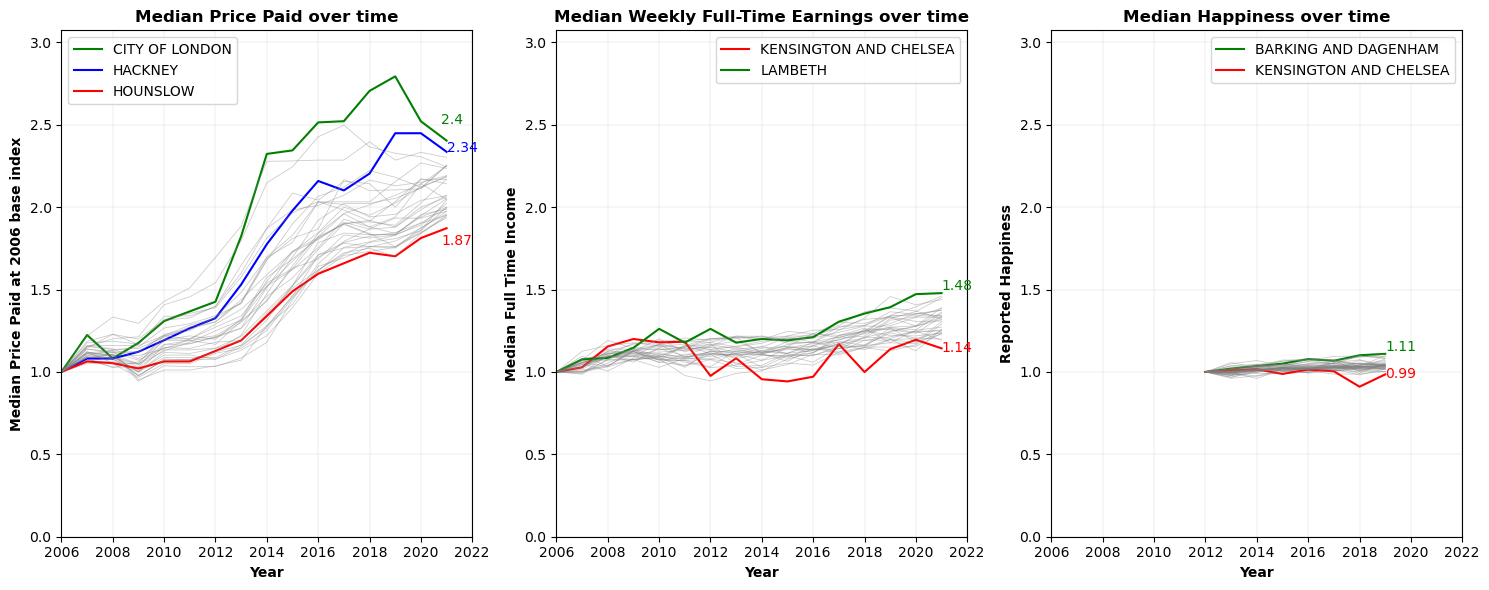

In [23]:
obj_one()

## Objective 2
### Explanation of Results

Objective 1 illustrated that Median Earnings did not experience the same level of growth as Median Price Paid from 2006 to 2021; however, the results from Objective 2 show that for the vast majority of boroughs within the Greater London area, there is a strong correlation between these two measures. Notably, more than half the boroughs saw a correlation of greater than 0.8. This implies that as an area's median house price increases, we can confidently state that we should see a corresponding increase in the median income in the area.

Interestingly, the data suggests that there is no correlation between these two factors for the borough of ```Kensington and Chelsea```. This is mostly likely driven by the almost negligible change in median earnings for the borough, as illustrated by Objective One, while seeing growth in the median price paid.

### Visualisation
The chart belows shows the Pearson Correlation between the Median Price Paid and Median Weekly Full-Time Earnings between 2006 and 2021, sorted in descending order of correlation strength.

The chart clearly shows that there is a strong correlation between the two factors for almost all the boroughs.

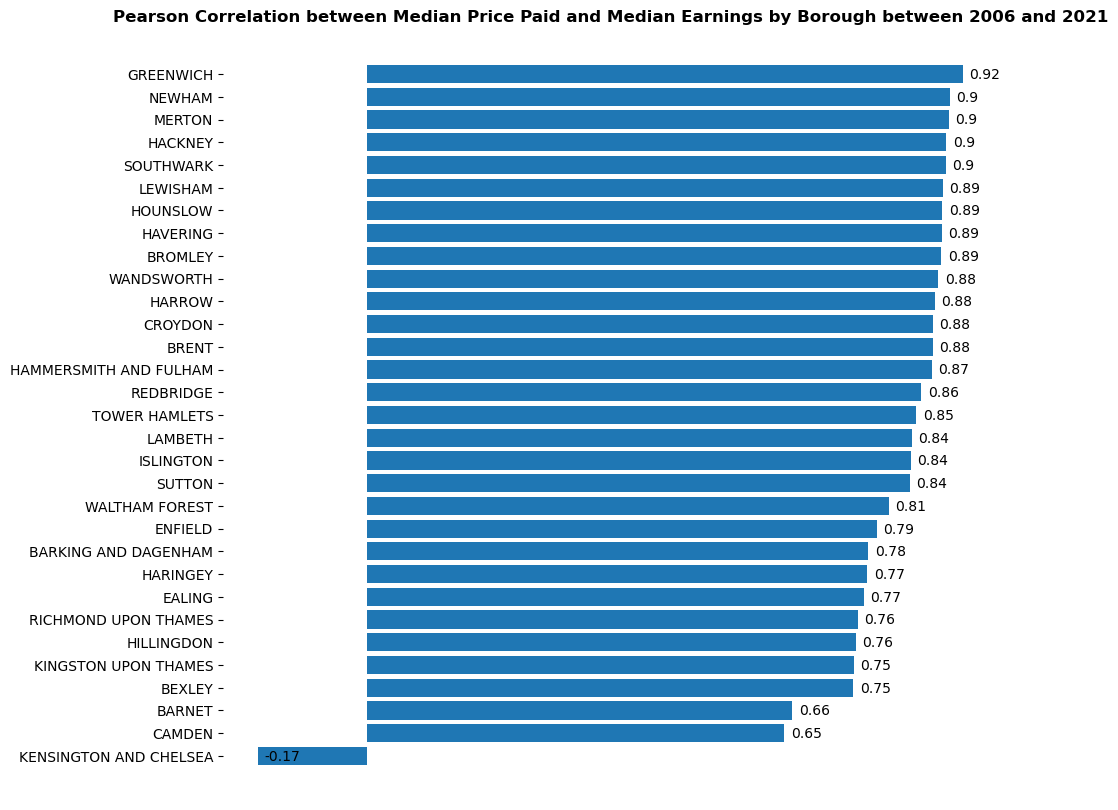

In [24]:
obj_two()

## Objective 3 _(if present)_
### Explanation of Results

Happiness is a subjective measure, however, the data suggests that for most boroughs, there is a positive correlation between how happy a borough is and the median income of that borough; this correlation is suggested to be moderate-to-strong for most boroughs.

Interestingly, we see that once again, the borough of ```Kensington and Chelsea```, has no correlation between these two measures; combining this with the observations from Objective 2, we could surmise that this borough is somewhat of an outlier borough, where resident income is not related to either the wealth of happiness of the residents in that borough.

Finally, we note that the correlation here is much weaker than in Objective 2, indicating that income is not as strongly related to happiness as it is to the price of the property in that region. This intuitively makes sense, as we would expect that there are quite a few more factors that play into how happy a person feels than simply their income.

### Visualisation
The chart below shows that for most boroughs, there is a moderate-to-strong positive correlation between personal income reported happiness. The borough of ```Brent``` shows the greatest correlation, while the borough of ```Kingston Upon Thames``` shows a moderate negative correlation.

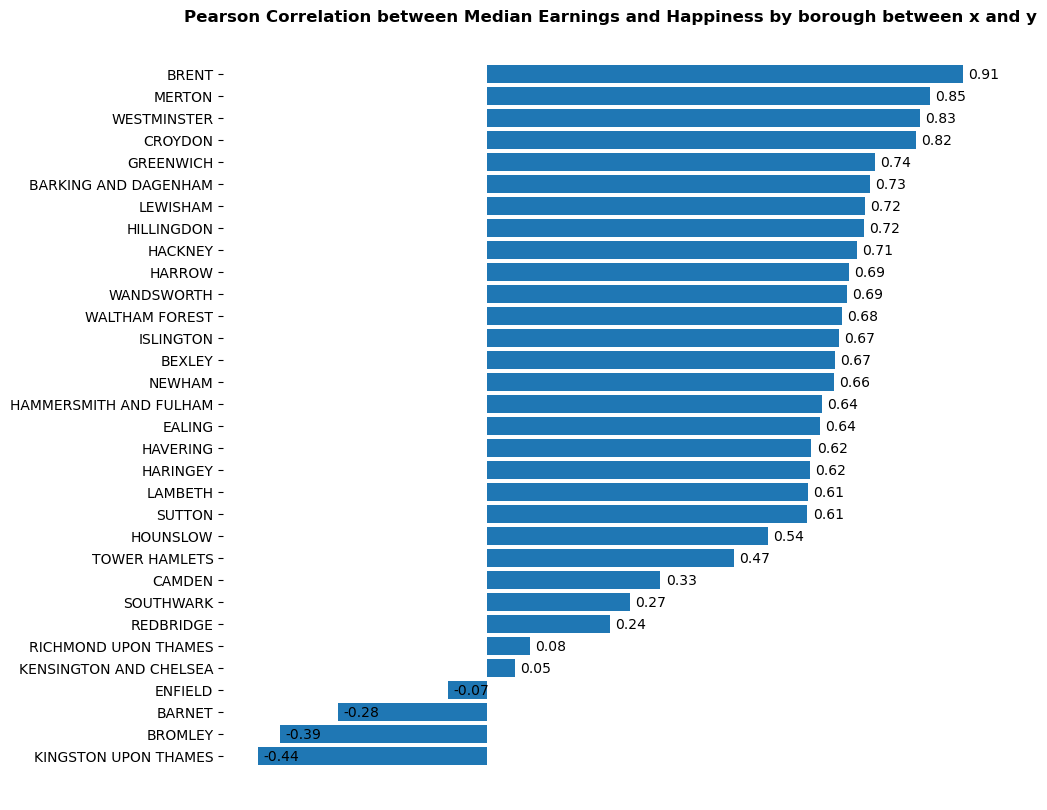

In [25]:
obj_three()

# Conclusion (5 marks)

### Achievements
As expected, the median earnings of the residents in a borough is strongly correlated with the median price paid for residential property in that borough; this hints at the observed phenomenon of 'gentrification', where previously 'poor' boroughs gradually become more attractive to higher income earners and increase the value of the properties in that area in a cycle.

Unexpectedly, the data also showed the happiness could be strongly correlated with income for some boroughs. We expected a much weaker correlation between these factors, as the old adage suggests that 'Money cannot buy happiness'. This idiom can now be challenged, particularly in those boroughs (such as ```Brent``` and ```Merton```) where the correlation between earnings and happiness was very strong.

### Limitations

This project was limited to three simple datasets, where a range of other factors were not considered. The price paid data was used as a proxy for the property value of the analysis, which excludes any properties that were not sold but still have intrinsic value (for example, properties passed down through generations). Additionally, this report does not consider the proportion of non-home-owners in a borough, nor the cost of rental. The data for well-being (and happiness) was also limited, and lacked the data required for more in-depth analysis.

Finally, the analysis only considered the growth of the median price paid, and not the relative differences in value between boroughs, which may play a factor into well-being.

### Future Work

In future work, we would want to further explore other impacts on property price and well-being - this could include measures such as noise pollution, availability and quality of public and social services, the nationalities of the residences and average residence tenure. Additionally, other well-being factors (e.g. anxiety, life satisfaction) should be explored to see how other economic measures could be correlated with a broader sense of well-being.